# pixell Demo: Map Generation, Targeted Point Stacking & Edge-Distance Histogram

This notebook demonstrates core **[pixell](https://github.com/simonsobs/pixell)** workflows:

1. **Generate a synthetic CMB-like sky map** on a CAR (Plate-Carrée) projection
2. **Place random background points** and visualise them on the map
3. **Define a `stack_locations` list** — the explicit positions to stack on
4. **Stack cutouts** centred only on the `stack_locations` and show results
5. **Histogram** the great-circle distance from each stacking location to the nearest map edge

> **Test case:** `stack_locations` is set to the positions of the 8 injected compact sources,
> so the stacked mean should show a clear central peak.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
from scipy.ndimage import gaussian_filter
from pixell import enmap, utils, reproject
import sys, os

# ── Point Python at the oriented_superclustering repo ─────────────────────────
REPO_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)

# ── Standard imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from pixell import enmap, utils

# ── oriented_superclustering imports ──────────────────────────────────────────
from stacking_functions import Chunk, StackGeometry, stackChunk, extractThumbnails

print("All imports OK")
print(f"  Repo root: {REPO_PATH}")

rng = np.random.default_rng(42)

# ── Plotting helpers ──────────────────────────────────────────────────────────
def sky_extent(m):
    """Return [ra_min, ra_max, dec_min, dec_max] in degrees for imshow extent."""
    pos = m.posmap()          # (2, ny, nx)  radians  [dec, ra]
    dec = np.degrees(pos[0])
    ra  = np.degrees(pos[1])
    return [ra.min(), ra.max(), dec.min(), dec.max()]


All imports OK
  Repo root: /pscratch/sd/r/rhlozek/oriented_superclustering/notebooks/..


In [49]:
path="/global/cfs/projectdirs/act/www/dr6_nilc/ymaps_20230220/ilc_actplanck_ymap.fits"
shape,wcs=enmap.read_fits_geometry(path, hdu=None, quick=True)
box = enmap.box(shape, wcs)   # shape (2,2): [[dec_min,ra_min],[dec_max,ra_max]] in radians
dec_min_big, ra_min_big = np.degrees(box[0])
dec_max_big, ra_max_big = np.degrees(box[1])
print(f"RA range: {ra_min_big:.2f} to {ra_max_big:.2f} deg")
print(f"Dec range: {dec_min_big:.2f} to {dec_max_big:.2f} deg")
min_safe_dist_bigmap = 50*np.degrees(enmap.pixsize(shape,wcs)*180/np.pi) #arbitrary number of pixels 
print(f"Minimum safe distance from edge of larger map: {min_safe_dist_bigmap:.6f} deg")
print(f"Pixel size:  = {np.degrees(enmap.pixsize(shape,wcs)*180/np.pi):.6f} deg")

RA range: 180.00 to -180.00 deg
Dec range: -63.00 to 23.00 deg
Minimum safe distance from edge of larger map: 0.002965 deg
Pixel size:  = 0.000059 deg


## Make skymap

In [2]:
rng = np.random.default_rng(42)

# ── Map geometry ──────────────────────────────────────────────────────────────
dec_range = np.array([-20.0,  20.0]) * utils.degree   # radians
ra_range  = np.array([-30.0,  30.0]) * utils.degree
res_deg   = 0.25                                        # degrees / pixel
res_rad   = res_deg * utils.degree

shape, wcs = enmap.geometry(
    pos=np.array([[dec_range[0], ra_range[0]],
                  [dec_range[1], ra_range[1]]]),
    res=res_rad,
    proj="car",
)
print(f"Map shape : {shape}  (ny={shape[-2]}, nx={shape[-1]})")

# ── Pink noise background ─────────────────────────────────────────────────────
white = rng.standard_normal(shape)
pink  = white.copy()
for sig in [2, 4, 8]:
    pink += gaussian_filter(white, sigma=sig)
pink /= pink.std()

# ── Inject 8 compact Gaussian sources ─────────────────────────────────────────
n_src   = 8
src_dec = (dec_range[0]+0.01*rng.random(n_src))*np.ones(n_src)   # rad
#rng.uniform(dec_range[0]*0.7, dec_range[1]*0.7, n_src)   # rad
src_ra  = rng.uniform(ra_range[0]*0.7,  ra_range[1]*0.7,  n_src)   # rad
src_amp = rng.uniform(5, 12, n_src)

sky_data = pink.copy()
pos = enmap.enmap(pink, wcs).posmap()   # (2, ny, nx)
for d, r, a in zip(src_dec, src_ra, src_amp):
    dist2 = (pos[0] - d)**2 + (pos[1] - r)**2
    sky_data += a * np.exp(-dist2 / (2*(utils.degree)**2))

imap = enmap.enmap(sky_data, wcs)   # <-- the "ACT map" we will stack
print(f"Map value range: [{imap.min():.2f}, {imap.max():.2f}]")


# Make some random points
import types

N_PTS = 30

cat = types.SimpleNamespace()
cat.RA    = np.degrees(rng.uniform(ra_range[0]  * 0.8, ra_range[1]  * 0.8, N_PTS))  # deg
cat.DEC   = np.degrees(rng.uniform(dec_range[0] * 0.8, dec_range[1] * 0.8, N_PTS))  # deg
cat.Z     = rng.uniform(0.4, 0.8, N_PTS)    # mock redshifts
cat.nObj  = N_PTS
cat.alpha = None   # no orientation angle → will use orient="original"

print(f"Catalogue: {cat.nObj} objects")
print(f"  RA  range : [{cat.RA.min():.2f}, {cat.RA.max():.2f}] deg")
print(f"  Dec range : [{cat.DEC.min():.2f}, {cat.DEC.max():.2f}] deg")
print(f"  Z   range : [{cat.Z.min():.3f}, {cat.Z.max():.3f}]")



Map shape : (160, 240)  (ny=160, nx=240)
Map value range: [-4.14, 24.74]
Catalogue: 30 objects
  RA  range : [-22.13, 23.60] deg
  Dec range : [-15.78, 15.48] deg
  Z   range : [0.406, 0.799]


## Make locations to stack on
`stack_locations` is a plain NumPy array of shape `(N_stack, 2)` with columns `[dec, ra]` in **radians**.

In this case we defined `N_stack` as the known positions of the 8 injected compact sources, but could also defined them as random locations.

In [3]:
# ── stack_locations: shape (Npoints, 2), columns [Dec, RA] in degrees ───────────────
stack_locations = np.column_stack([
    np.degrees(src_dec),   # Dec [deg]
    np.degrees(src_ra),    # RA  [deg]
])

# stack_locations = np.column_stack([
#     cat.DEC,   # Dec [deg]
#     cat.RA,    # RA  [deg]
# ])

Npts = len(stack_locations)
print(f"Stacking on {Npts} locations (injected source positions):")
print(f"{'#':>3}  {'Dec [deg]':>12}  {'RA [deg]':>12}")
print("-" * 32)
for i, (d, r) in enumerate(stack_locations):
    print(f"{i:>3}  {d:>12.4f}  {r:>12.4f}")


Stacking on 8 locations (injected source positions):
  #     Dec [deg]      RA [deg]
--------------------------------
  0      -19.9511        1.1396
  1      -19.4693        5.7352
  2      -19.5192      -18.7375
  3      -19.6930      -16.9670
  4      -19.5738      -17.5387
  5      -19.7986        3.9870
  6      -19.6472       -3.6579
  7      -19.7632        0.0025


## Plotting the bigger map with All Point Locations
We make a plot of the bigger map with the locations on them so we can see where they are visually

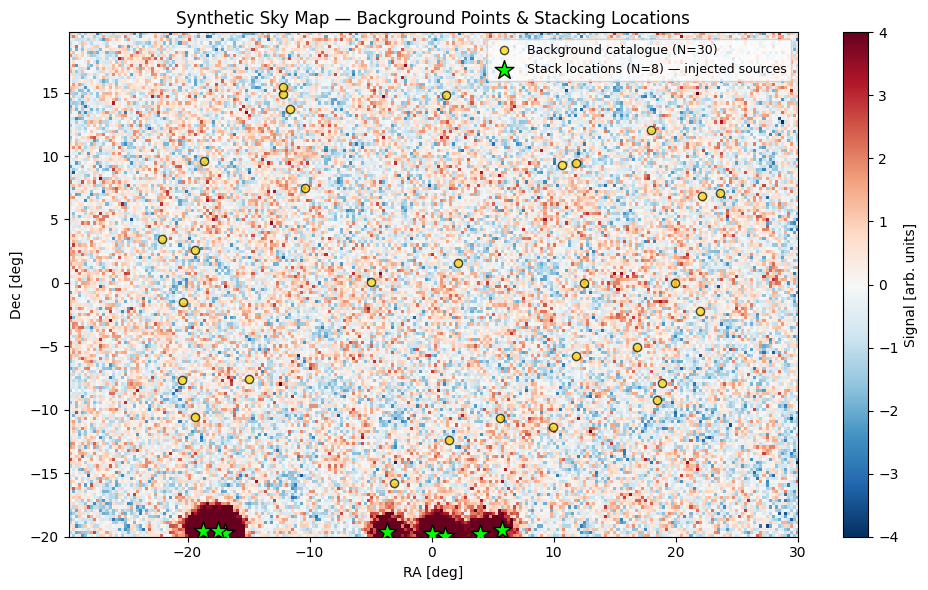

In [4]:
def sky_extent(m):
    """[ra_min, ra_max, dec_min, dec_max] in degrees for imshow extent."""
    p = m.posmap()
    return [np.degrees(p[1].min()), np.degrees(p[1].max()),
            np.degrees(p[0].min()), np.degrees(p[0].max())]

ext = sky_extent(imap)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(imap, origin="lower", extent=ext,
               cmap="RdBu_r", vmin=-4, vmax=4, aspect="auto")
plt.colorbar(im, ax=ax, label="Signal [arb. units]")

ax.scatter(cat.RA, cat.DEC, c="gold", edgecolors="k", s=35, zorder=4,
           alpha=0.7, label=f"Background catalogue (N={N_PTS})")
ax.scatter(stack_locations[:, 1], stack_locations[:, 0],
           marker="*", c="lime", edgecolors="k", s=200, zorder=6,
           label=f"Stack locations (N={Npts}) — injected sources")

ax.set_xlabel("RA [deg]"); ax.set_ylabel("Dec [deg]")
ax.set_title("Synthetic Sky Map — Background Points & Stacking Locations")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("map_with_locations.png", dpi=150)
plt.show()


## Build individual thumbnails and chunk

shape is (41, 41)
Cutout geometry: 41×41 pixels (10.0×10.0 deg)
Chunk: 8 objects
Background chunk: 30 objects
Thumbnail cube: (8, 41, 41)  [N_src × ny × nx]


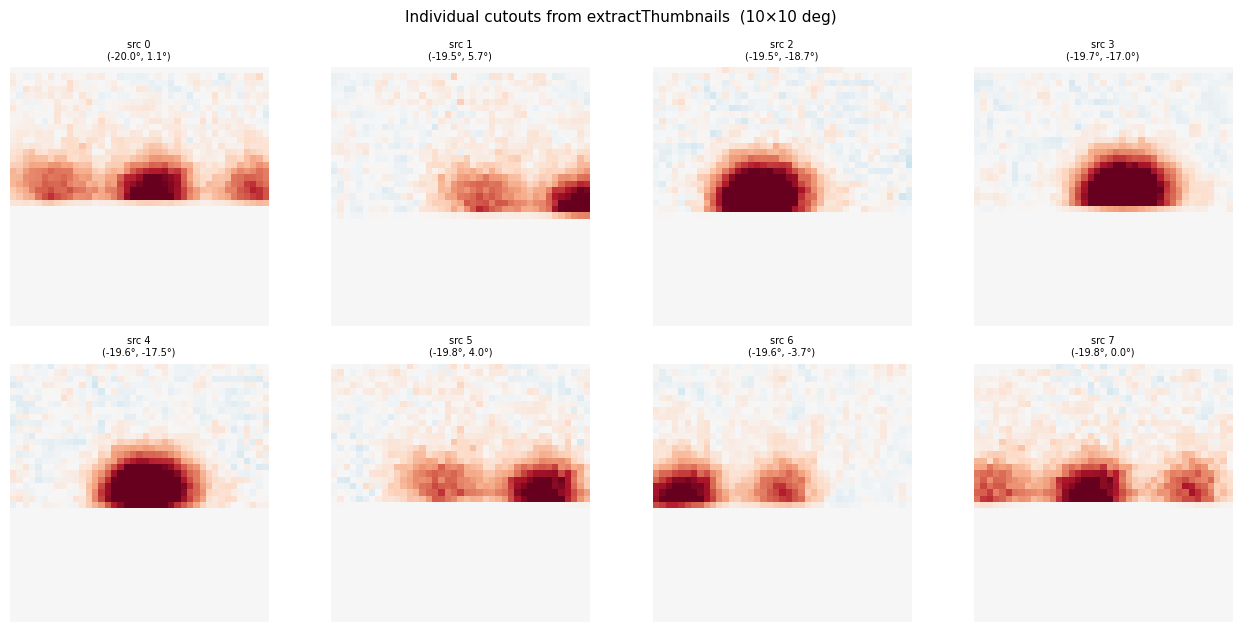

In [5]:
# ── StackGeometry ─────────────────────────────────────────────────────────────
CUTOUT_RAD_DEG  = 5.0    # half-width [deg]
CUTOUT_RES_DEG  = res_deg  # match the map resolution [deg/pixel]

geom = StackGeometry(
    cutout_rad_deg=CUTOUT_RAD_DEG,
    cutout_resolution_deg=CUTOUT_RES_DEG,
)
print(f"Cutout geometry: {geom.shape[0]}×{geom.shape[1]} pixels "
      f"({CUTOUT_RAD_DEG*2:.1f}×{CUTOUT_RAD_DEG*2:.1f} deg)")

# ── Chunk for the stacking locations ─────────────────────────────────────────
# Chunk takes RA and DEC in degrees.  alpha=None → orient="original" (no rotation).
stack_chunk = Chunk(
    RA    = stack_locations[:, 1],   # deg
    DEC   = stack_locations[:, 0],   # deg
    alpha = None,
)
print(f"Chunk: {stack_chunk.nObj} objects")



# ── Chunk for the full background catalogue ───────────────────────────────────
bg_chunk = Chunk(RA=cat.RA, DEC=cat.DEC)
print(f"Background chunk: {bg_chunk.nObj} objects")


# orient="original" → no rotation, exact cutout size
thumbs = extractThumbnails(
    iChunk = stack_chunk,
    geom   = geom,
    imap   = imap,
    orient = "original",
)
print(f"Thumbnail cube: {thumbs.shape}  "
      f"[N_src × ny × nx]")

# ── Grid of all individual cutouts ───────────────────────────────────────────
ncols = 4
nrows = -(-Npts // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2*nrows))
axes = axes.ravel()
vmax = np.nanpercentile(np.abs(thumbs), 98)

for i, ax in enumerate(axes):
    if i < Npts:
        ax.imshow(thumbs[i], origin="lower", cmap="RdBu_r",
                  vmin=-vmax, vmax=vmax, aspect="equal")
        ax.set_title(
            f"src {i}\n"
            f"({stack_locations[i,0]:.1f}°, {stack_locations[i,1]:.1f}°)",
            fontsize=7,
        )
    ax.axis("off")

fig.suptitle(
    f"Individual cutouts from extractThumbnails  "
    f"({CUTOUT_RAD_DEG*2:.0f}×{CUTOUT_RAD_DEG*2:.0f} deg)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("individual_cutouts.png", dpi=150)
plt.show()


## Stack with `stackChunk`

We demonstrate with `"original"` (the direct mean) and `"random"` (null test).

stacked_orig shape: (41, 41)
  peak value : 14.2417
  mean value : 1.0924

stacked_rand shape: (41, 41)
  peak value (null): 14.2417


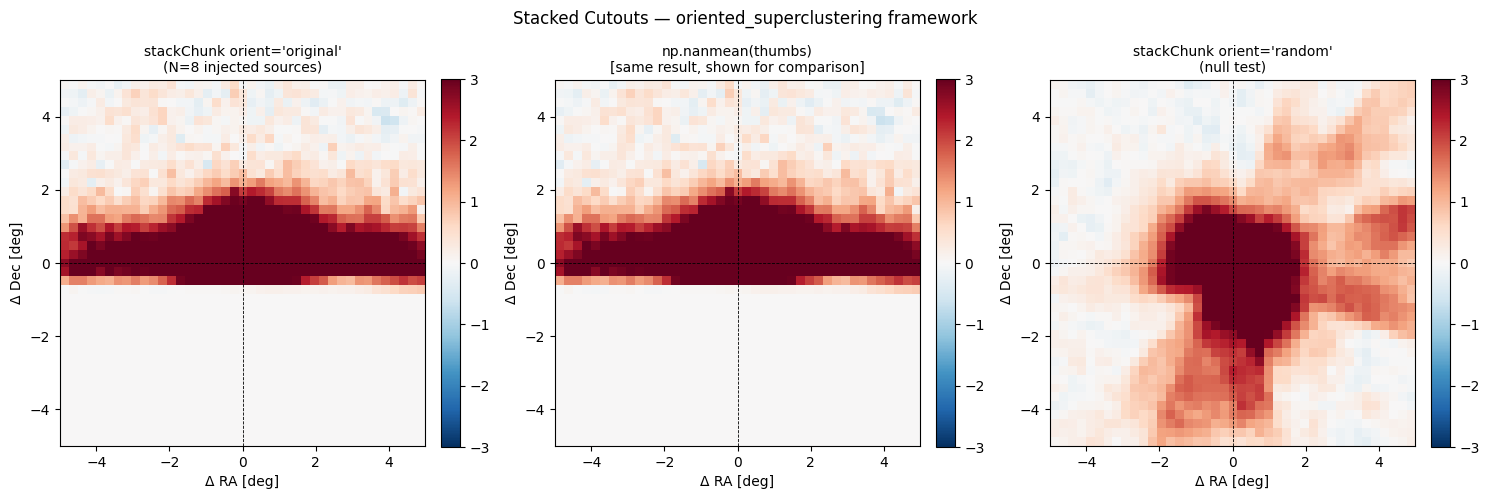

In [6]:
# ── Orient = "original": plain co-add ────────────────────────────────────────
stacked_orig = stackChunk(
    iChunk = stack_chunk,
    geom   = geom,
    imap   = imap,
    orient = "original",
)
print(f"stacked_orig shape: {stacked_orig.shape}")
print(f"  peak value : {stacked_orig.max():.4f}")
print(f"  mean value : {stacked_orig.mean():.4f}")

# ── Orient = "random": null-test stack ────────────────────────────────────────
# Supply dummy alpha=0 for all objects (stackChunk will override with random)
stack_chunk_rand = Chunk(
    RA    = stack_locations[:, 1],
    DEC   = stack_locations[:, 0],
    alpha = np.zeros(Npts),   # required placeholder when orient != "original"
)
stacked_rand = stackChunk(
    iChunk = stack_chunk_rand,
    geom   = geom,
    imap   = imap,
    orient = "random",
)
print(f"\nstacked_rand shape: {stacked_rand.shape}")
print(f"  peak value (null): {stacked_rand.max():.4f}")

extent_deg = CUTOUT_RAD_DEG  # symmetric half-extent

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

panels = [
    (stacked_orig,                         f"stackChunk orient='original'\n(N={Npts} injected sources)"),
    (np.nanmean(thumbs, axis=0),           f"np.nanmean(thumbs)\n[same result, shown for comparison]"),
    (stacked_rand,                         f"stackChunk orient='random'\n(null test)"),
]
for ax, (data, title) in zip(axes, panels):
    im = ax.imshow(
        data, origin="lower",
        extent=[-extent_deg, extent_deg, -extent_deg, extent_deg],
        cmap="RdBu_r", vmin=-3, vmax=3, aspect="equal",
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axhline(0, color="k", lw=0.6, ls="--")
    ax.axvline(0, color="k", lw=0.6, ls="--")
    ax.set_xlabel("Δ RA [deg]"); ax.set_ylabel("Δ Dec [deg]")
    ax.set_title(title, fontsize=10)

plt.suptitle("Stacked Cutouts — oriented_superclustering framework", fontsize=12)
plt.tight_layout()
plt.savefig("stacked_cutouts.png", dpi=150)
plt.show()



## Make a radial profile

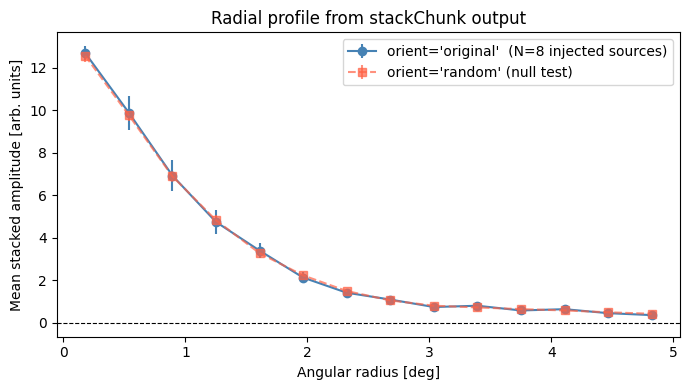

In [7]:
def radial_profile(img, r_bins_deg, extent_deg):
    """Circularly-averaged profile of a square flat-sky image."""
    ny, nx = img.shape
    y = np.linspace(-extent_deg, extent_deg, ny)
    x = np.linspace(-extent_deg, extent_deg, nx)
    X, Y = np.meshgrid(x, y, indexing='xy')
    R = np.sqrt(X**2 + Y**2)
    
    r_centres = 0.5 * (r_bins_deg[:-1] + r_bins_deg[1:])
    means, errs = [], []
    for r0, r1 in zip(r_bins_deg[:-1], r_bins_deg[1:]):
        mask = (R >= r0) & (R < r1)
        pix  = img[mask]
        means.append(np.mean(pix))
        errs.append(np.std(pix) / np.sqrt(len(pix)) if len(pix) > 0 else np.nan)
    return r_centres, np.array(means), np.array(errs)

r_bins = np.linspace(0, CUTOUT_RAD_DEG, 15)
r_c, prof_orig, err_orig = radial_profile(stacked_orig,  r_bins, CUTOUT_RAD_DEG)
r_c, prof_rand, err_rand = radial_profile(stacked_rand,  r_bins, CUTOUT_RAD_DEG)

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.errorbar(r_c, prof_orig, yerr=err_orig, fmt="o-", color="steelblue",
            label=f"orient='original'  (N={Npts} injected sources)")
ax.errorbar(r_c, prof_rand, yerr=err_rand, fmt="s--", color="tomato",
            alpha=0.7, label="orient='random' (null test)")
ax.set_xlabel("Angular radius [deg]")
ax.set_ylabel("Mean stacked amplitude [arb. units]")
ax.set_title("Radial profile from stackChunk output")
ax.legend()
plt.tight_layout()
plt.savefig("radial_profile.png", dpi=150)
plt.show()



## Compute the minimum great-circle distance from each position in
`stack_locations` to the four boundary edges of the map.

| Edge   | value            |
|--------|------------------|
| North  | `dec = dec_max`  |
| South  | `dec = dec_min`  |
| East   | `ra  = ra_max`   |
| West   | `ra  = ra_min`   |

North/South distance ≈ |Δdec|; East/West distance ≈ cos(dec)·|Δra|.


In [8]:
pos_all     = imap.posmap()
dec_min_map = pos_all[0].min(); dec_max_map = pos_all[0].max()
ra_min_map  = pos_all[1].min(); ra_max_map  = pos_all[1].max()

def dist_to_nearest_edge(dec_rad, ra_rad):
    """Minimum angular distance [rad] from (dec, ra) to the map boundary."""
    cos_dec = np.cos(dec_rad)
    return np.minimum.reduce([
        dec_max_map - dec_rad,          # to north edge
        dec_rad   - dec_min_map,        # to south edge
        cos_dec * (ra_max_map - ra_rad),  # to east edge
        cos_dec * (ra_rad - ra_min_map),  # to west edge
    ])

# Distances for the stacking locations
sl_dec_rad = np.radians(stack_locations[:, 0])
sl_ra_rad  = np.radians(stack_locations[:, 1])
dist_deg   = np.degrees(dist_to_nearest_edge(sl_dec_rad, sl_ra_rad))

print(f"Edge distances for {Npts} stacking locations:")
print(f"  Min    : {dist_deg.min():.2f} deg")
print(f"  Max    : {dist_deg.max():.2f} deg")
print(f"  Mean   : {dist_deg.mean():.2f} deg")

# Warn if any cutout might clip the map boundary
min_safe_dist = CUTOUT_RAD_DEG * np.sqrt(2)   # diagonal of a square cutout
n_close = np.sum(dist_deg < min_safe_dist)
if n_close:
    print(f"\n⚠️  {n_close} source(s) are within {min_safe_dist:.1f} deg of the map edge "
          f"(cutout diagonal). Their cutouts may be clipped.")
else:
    print(f"\n✓  All sources are at least {min_safe_dist:.1f} deg from the map edge.")


Edge distances for 8 stacking locations:
  Min    : 0.05 deg
  Max    : 0.53 deg
  Mean   : 0.32 deg

⚠️  8 source(s) are within 7.1 deg of the map edge (cutout diagonal). Their cutouts may be clipped.


## Make plot

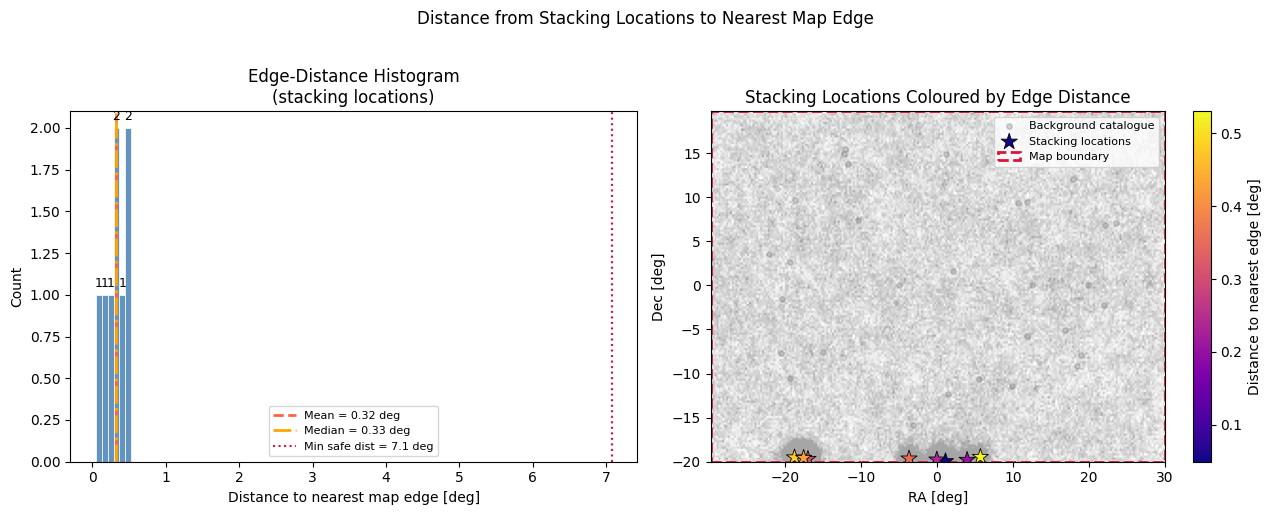

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: histogram ───────────────────────────────────────────────────────────
ax = axes[0]
n, bins, patches = ax.hist(dist_deg, bins=6, color="steelblue",
                            edgecolor="white", linewidth=0.6, alpha=0.85)
ax.axvline(dist_deg.mean(),   color="tomato",  lw=2, ls="--",
           label=f"Mean = {dist_deg.mean():.2f} deg")
ax.axvline(np.median(dist_deg), color="orange", lw=2, ls="-.",
           label=f"Median = {np.median(dist_deg):.2f} deg")
ax.axvline(CUTOUT_RAD_DEG * np.sqrt(2), color="crimson", lw=1.5, ls=":",
           label=f"Min safe dist = {CUTOUT_RAD_DEG*np.sqrt(2):.1f} deg")
for rect in patches:
    h = rect.get_height()
    if h > 0:
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.03,
                str(int(h)), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Distance to nearest map edge [deg]")
ax.set_ylabel("Count")
ax.set_title("Edge-Distance Histogram\n(stacking locations)")
ax.legend(fontsize=8)

# ── Right: scatter map ────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.imshow(imap, origin="lower", extent=ext, cmap="Greys",
           alpha=0.35, vmin=-3, vmax=3, aspect="auto")
ax2.scatter(cat.RA, cat.DEC, c="grey", s=15, alpha=0.35, zorder=3,
            label="Background catalogue")
sc = ax2.scatter(stack_locations[:, 1], stack_locations[:, 0],
                 c=dist_deg, cmap="plasma", s=150,
                 edgecolors="k", linewidths=0.6, marker="*",
                 zorder=6, label="Stacking locations")
plt.colorbar(sc, ax=ax2, label="Distance to nearest edge [deg]")
rect_patch = plt.Rectangle(
    (np.degrees(ra_min_map), np.degrees(dec_min_map)),
    np.degrees(ra_max_map - ra_min_map),
    np.degrees(dec_max_map - dec_min_map),
    fill=False, edgecolor="crimson", lw=2, ls="--", label="Map boundary",
)
ax2.add_patch(rect_patch)
ax2.set_xlabel("RA [deg]"); ax2.set_ylabel("Dec [deg]")
ax2.set_title("Stacking Locations Coloured by Edge Distance")
ax2.legend(fontsize=8, loc="upper right")

plt.suptitle("Distance from Stacking Locations to Nearest Map Edge",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("edge_distance_histogram.png", dpi=150)
plt.show()
